### Weight Estimation Lab 
Avoinics Payload:
$W_{avionics}$ = 2500 lb  
Air-to-Air Combat: $W_{ordinance}$ = 2508 lb  
Air-to-Ground Strike: $W_{ordinance}$ = 4372 lb  
$W_{crew}$ = 440 lb (assuming 2 pilots, 220 lb each)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Fuel Fraction from Martins
low-bypass turbofan specific fuel consumption  
Cruise: 0.8 [1/hr]  
Loiter 0.7 [1/hr]  

Range: 700 nmi

Loiter: 20 min

Cruise Fuel Fraction (Equation 2.30 in Martins, 2021): $$ \frac{W3}{W2} = exp\big(\frac{−Rc}{V(L/D)}\big)$$

Loiter Fuel Fraction (Equation 2.31 in Martins, 2021): $$ \frac{W4}{W3} = exp\big(\frac{−Ec}{(L/D)}\big)$$

In [8]:
num_pilot = 2
num_crew = 12
num_crew = num_pilot + num_crew
num_passengers = 314
avg_wt_person = 82  # kg
avg_wt_luggage = 27 # kg

W_crew = num_crew * (avg_wt_person + avg_wt_luggage) # kg
print("W_crew: " + str(W_crew) + " kg")

W_payload = num_passengers * (avg_wt_person + avg_wt_luggage) # kg
print("W_payload: " + str(W_payload) + " kg")

W_crew: 1526 kg
W_payload: 34226 kg


In [9]:
L_D_max = 18
L_D = 0.94 * L_D_max
R = 9150            # nmi
E = 30 / 60         # min --> hr
c = 0.52            # lb/(lbf hr)
V = 251 * 1.94      # m/s --> knots

W3_W2 = np.exp((-R*c) / (V*L_D))  # cruise
print("Cruise Fuel Fraction (W3/W2): " + str(round(W3_W2, 3)))

W4_W3 = np.exp((-E*c) / (L_D))    # loiter/descent
print("Loiter Fuel Fraction (W4/W3): " + str(round(W4_W3, 3)))

Cruise Fuel Fraction (W3/W2): 0.561
Loiter Fuel Fraction (W4/W3): 0.985


In [10]:
W1_W0 = 0.970   # engine start & takeoff
W2_W1 = 0.985   # climb
W5_W4 = 0.995   # landing

W5_W0 = W5_W4 * W4_W3 * W3_W2 * W2_W1 * W1_W0
print("Final Fuel Fraction (W5/W0): " + str(round(W5_W0, 3)))

Final Fuel Fraction (W5/W0): 0.525


In [13]:
Wf_W0 = (1 - W5_W0) * 1.06    # compute fuel fraction
print("Total Fuel Fraction Wf/W0: {:.3f}".format(Wf_W0))

Total Fuel Fraction Wf/W0: 0.503


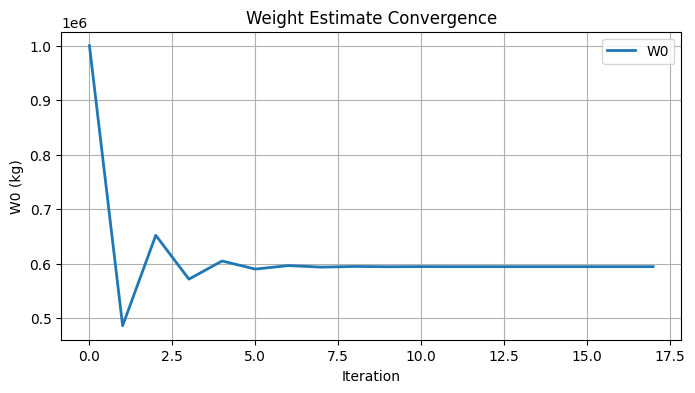

In [14]:
W0 = 1000000      # kg, initial empty weight guess
W0_history = []   # list of all W0 guesses for plot
err = 1e-6        # relative convergence tolerance
delta = 2*err     # any value greater than the tolerance

A = 0.97          # From Raymer Table 3.1
C = -0.06         # From Raymer Table 3.1

while delta > err:
    W0_history.append(W0)                                 # add latest value to list
    We_W0 = A*W0**C                                       # kg, Compute empty weight ratio
    W0_new = (W_crew + W_payload) / (1 - Wf_W0 - We_W0)   # kg, compute new TOGW
    delta = abs(W0_new - W0) / abs(W0_new)                # find difference between last guess and current guess  
    W0 = W0_new                                           # kg, update TOGW value
    
W0_history = np.array(W0_history)  # convert list to array

# Plot Convergence
plt.figure(figsize=(8,4))
plt.title('Weight Estimate Convergence')
plt.xlabel("Iteration")
plt.ylabel("W0 (kg)")
plt.plot(W0_history, label='W0', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [15]:
We = We_W0 * W0
print("Empty Weight: " + str(round(We)) + " kg")
print("Our regression's Empty Weight Fraction (We/W0): " + str(round(We/W0 ,3)))

Empty Weight: 259622 kg
Our regression's Empty Weight Fraction (We/W0): 0.437


In [16]:
print("Takeoff Gross Weight: " + str(round(W0)) + " kg")

Takeoff Gross Weight: 594305 kg


|Mission Segment |      | Fuel Fraction |
|----------------|------|---------------|
|Take-off        |W1/W0 | 0.970         |
|Climb           |      | 0.985         |
|Cruise          |      |               |
|Descend         |      | 0.990         |
|Land            |      | 0.995         |